# Lab Experiment: Comparison of Logistic Regression and K-Nearest Neighbors (KNN) Classifiers

## Aim

To implement Logistic Regression and K-Nearest Neighbors (KNN) classifiers on the Breast Cancer Wisconsin (Diagnostic) dataset and compare their performance using standard classification evaluation metrics.

## Objectives

- To preprocess the dataset for classification.
- To implement Logistic Regression and KNN classifiers using Scikit-learn.
- To evaluate both models using standard performance metrics.
- To compare both classifiers and identify the better classifier.

## Dataset

- **Dataset Name:** Breast Cancer Wisconsin (Diagnostic)
- **Source:** UCI Machine Learning Repository
- **Dataset Link:** [Breast Cancer Wisconsin (Diagnostic)](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic)

## Import Required Libraries

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

## 1. Load Breast Cancer Dataset

In [2]:
# 1. Load Breast Cancer Dataset from the local dataset directory
dataset_path = (
    "/mnt/data/college/4_tri/ML-Lab-2547121/"
    "datasets/breast+cancer+wisconsin+diagnostic/wdbc.data"
)

measurements = [
    "radius", "texture", "perimeter", "area", "smoothness",
    "compactness", "concavity", "concave_points", "symmetry",
    "fractal_dimension"
]
feature_names = (
    [f"mean_{name}" for name in measurements]
    + [f"{name}_se" for name in measurements]
    + [f"worst_{name}" for name in measurements]
)
column_names = ["id", "diagnosis"] + feature_names

raw_df = pd.read_csv(dataset_path, header=None, names=column_names)

X = raw_df.drop(columns=["id", "diagnosis"])          # Features
y = raw_df["diagnosis"].map({"M": 0, "B": 1})      # Target
target_names = np.array(["malignant", "benign"])

print("Dataset loaded successfully from:")
print(dataset_path)
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Dataset loaded successfully from:
/mnt/data/college/4_tri/ML-Lab-2547121/datasets/breast+cancer+wisconsin+diagnostic/wdbc.data
Feature matrix shape: (569, 30)
Target shape: (569,)


## 2. Convert into DataFrame and Perform EDA

In [3]:
# 2. Convert into DataFrame
df = X.copy()
df["target"] = y

print("First five rows:")
display(df.head())

print("\nTarget Classes:")
print(target_names)

print("\nDataset Information:")
df.info()

print("\nClass Distribution:")
print(df["target"].value_counts().rename(index={0: "malignant", 1: "benign"}))

print("\nDescriptive Statistics:")
display(df.drop(columns="target").describe().T)

First five rows:


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,...,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



Target Classes:
['malignant' 'benign']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean_radius              569 non-null    float64
 1   mean_texture             569 non-null    float64
 2   mean_perimeter           569 non-null    float64
 3   mean_area                569 non-null    float64
 4   mean_smoothness          569 non-null    float64
 5   mean_compactness         569 non-null    float64
 6   mean_concavity           569 non-null    float64
 7   mean_concave_points      569 non-null    float64
 8   mean_symmetry            569 non-null    float64
 9   mean_fractal_dimension   569 non-null    float64
 10  radius_se                569 non-null    float64
 11  texture_se               569 non-null    float64
 12  perimeter_se             569 non-null    float64
 13  area_se                  569 

,count,mean,std,min,25%,50%,75%,max
mean_radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean_texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean_perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean_area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean_smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean_compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean_concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean_concave_points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean_symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean_fractal_dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


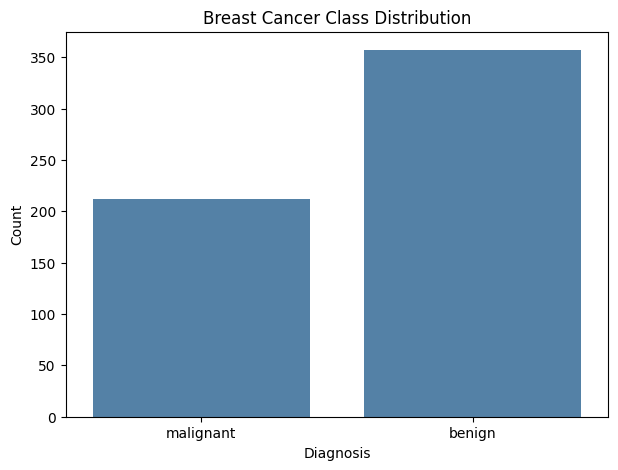

In [4]:
# Visualize the target class distribution
plt.figure(figsize=(7, 5))
sns.countplot(x=df["target"], order=[0, 1], color="steelblue")
plt.xticks([0, 1], target_names)
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.title("Breast Cancer Class Distribution")
plt.show()

### EDA Observations

- The dataset contains 569 samples and 30 numerical features.
- The target contains malignant and benign classes.
- Benign samples are more frequent than malignant samples.

## 3. Check Missing Values and Prepare the Dataset

In [5]:
# Check missing values
print("Missing values in each column:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

# Separate features and target after checking the data
X = df.drop(columns="target")
y = df["target"]

Missing values in each column:
mean_radius                0
mean_texture               0
mean_perimeter             0
mean_area                  0
mean_smoothness            0
mean_compactness           0
mean_concavity             0
mean_concave_points        0
mean_symmetry              0
mean_fractal_dimension     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
worst_radius               0
worst_texture              0
worst_perimeter            0
worst_area                 0
worst_smoothness           0
worst_compactness          0
worst_concavity            0
worst_concave_points       0
worst_symmetry             0
worst_fractal_dimension    0
target                     0
dtype: int64

Total missing values: 0


### Preprocessing Observation

- The dataset has no missing values.
- Therefore, missing-value imputation is not required.
- Feature scaling is applied after the train-test split.

## 4. Split Dataset into Training and Testing Sets

In [6]:
# 3. Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


## 5. Feature Scaling

In [7]:
# 4. Feature Scaling
# Scaling is important because KNN is distance-based and Logistic Regression
# performs better when features are on a similar scale.
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 6. Create and Train Logistic Regression Model

In [8]:
# 5. Create Logistic Regression Model
logistic_model = LogisticRegression(max_iter=1000, random_state=42)

# 6. Train the model
logistic_model.fit(X_train, y_train)

# 7. Prediction
logistic_pred = logistic_model.predict(X_test)

# 8. Probability Prediction
logistic_probability = logistic_model.predict_proba(X_test)

print("Predicted Probabilities (first five samples):")
print(logistic_probability[:5])

Predicted Probabilities (first five samples):
[[1.13590250e-01 8.86409750e-01]
 [9.99990991e-01 9.00936206e-06]
 [9.96920905e-01 3.07909541e-03]
 [5.10134225e-04 9.99489866e-01]
 [6.06389713e-05 9.99939361e-01]]


## 7. Create and Train KNN Model

In [9]:
# Create K-Nearest Neighbors Model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train, y_train)

# Prediction
knn_pred = knn_model.predict(X_test)

## 8. Evaluate Logistic Regression Model

Malignant (`0`) is treated as the positive class for precision, recall, and F1 score.

In [10]:
# Logistic Regression evaluation
logistic_accuracy = accuracy_score(y_test, logistic_pred)
logistic_precision = precision_score(y_test, logistic_pred, pos_label=0)
logistic_recall = recall_score(y_test, logistic_pred, pos_label=0)
logistic_f1 = f1_score(y_test, logistic_pred, pos_label=0)
logistic_cm = confusion_matrix(y_test, logistic_pred)

print("Accuracy:", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall:", logistic_recall)
print("F1 Score:", logistic_f1)

print("\nConfusion Matrix:")
print(logistic_cm)

print("\nClassification Report:")
print(classification_report(y_test, logistic_pred, target_names=target_names))

Accuracy: 0.9736842105263158
Precision: 0.9761904761904762
Recall: 0.9534883720930233
F1 Score: 0.9647058823529412

Confusion Matrix:
[[41  2]
 [ 1 70]]

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        43
      benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## 9. Evaluate KNN Model

In [11]:
# KNN evaluation
knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred, pos_label=0)
knn_recall = recall_score(y_test, knn_pred, pos_label=0)
knn_f1 = f1_score(y_test, knn_pred, pos_label=0)
knn_cm = confusion_matrix(y_test, knn_pred)

print("Accuracy:", knn_accuracy)
print("Precision:", knn_precision)
print("Recall:", knn_recall)
print("F1 Score:", knn_f1)

print("\nConfusion Matrix:")
print(knn_cm)

print("\nClassification Report:")
print(classification_report(y_test, knn_pred, target_names=target_names))

Accuracy: 0.9473684210526315
Precision: 0.9302325581395349
Recall: 0.9302325581395349
F1 Score: 0.9302325581395349

Confusion Matrix:
[[40  3]
 [ 3 68]]

Classification Report:


              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        43
      benign       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



## 10. Visualize Confusion Matrices

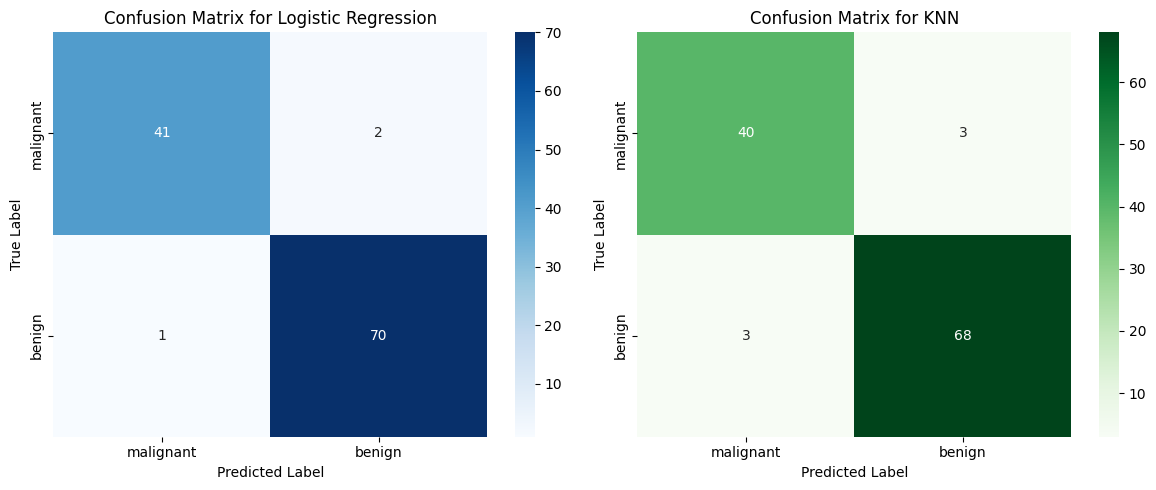

In [12]:
# Visualize the Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
    ax=axes[0]
)
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")
axes[0].set_title("Confusion Matrix for Logistic Regression")

sns.heatmap(
    knn_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=target_names,
    yticklabels=target_names,
    ax=axes[1]
)
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")
axes[1].set_title("Confusion Matrix for KNN")

plt.tight_layout()
plt.show()

## 11. Visualizing the Sigmoid Function

The sigmoid function converts the Logistic Regression linear score (`z`) into a probability between 0 and 1.

In [13]:
print("Intercept:")
print(logistic_model.intercept_)

print("\nCoefficients:")
print(logistic_model.coef_)

# Take one sample
sample = X_test[0]

# Calculate z
z = np.dot(logistic_model.coef_, sample) + logistic_model.intercept_
print("\nz value:", z)

# Apply sigmoid
prob = 1 / (1 + np.exp(-z))
print("Probability:", prob)

Intercept:
[0.44558453]

Coefficients:
[[-0.43190368 -0.38732553 -0.39343248 -0.46521006 -0.07166728  0.54016395
  -0.8014581  -1.11980408  0.23611852  0.07592093 -1.26817815  0.18887738
  -0.61058302 -0.9071857  -0.31330675  0.68249145  0.17527452 -0.3112999
   0.50042502  0.61622993 -0.87984024 -1.35060559 -0.58945273 -0.84184594
  -0.54416967  0.01611019 -0.94305313 -0.77821726 -1.20820031 -0.15741387]]

z value: [2.05458164]
Probability: [0.88640975]


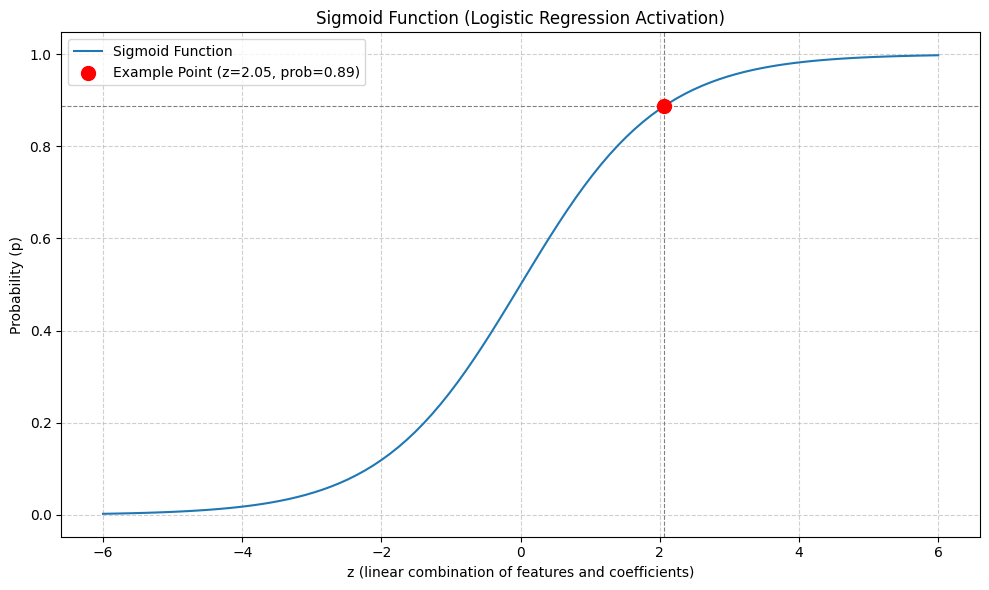

In [14]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Generate a range of z values
z_values = np.linspace(-6, 6, 100)

# Calculate sigmoid probabilities
sigmoid_probs = sigmoid(z_values)

plt.figure(figsize=(10, 6))
plt.plot(z_values, sigmoid_probs, label="Sigmoid Function")

# Highlight the z value and probability from the sample
plt.scatter(
    z[0],
    prob[0],
    color="red",
    s=100,
    zorder=5,
    label=f"Example Point (z={z[0]:.2f}, prob={prob[0]:.2f})"
)
plt.axvline(x=z[0], color="gray", linestyle="--", linewidth=0.8)
plt.axhline(y=prob[0], color="gray", linestyle="--", linewidth=0.8)

plt.title("Sigmoid Function (Logistic Regression Activation)")
plt.xlabel("z (linear combination of features and coefficients)")
plt.ylabel("Probability (p)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

## 12. Custom Logistic Regression Using Gradient Descent

The custom function below trains Logistic Regression using gradient descent and records binary cross-entropy loss. The required comparison table remains based on the Scikit-learn classifiers.

Custom Logistic Regression Accuracy: 0.9824561403508771


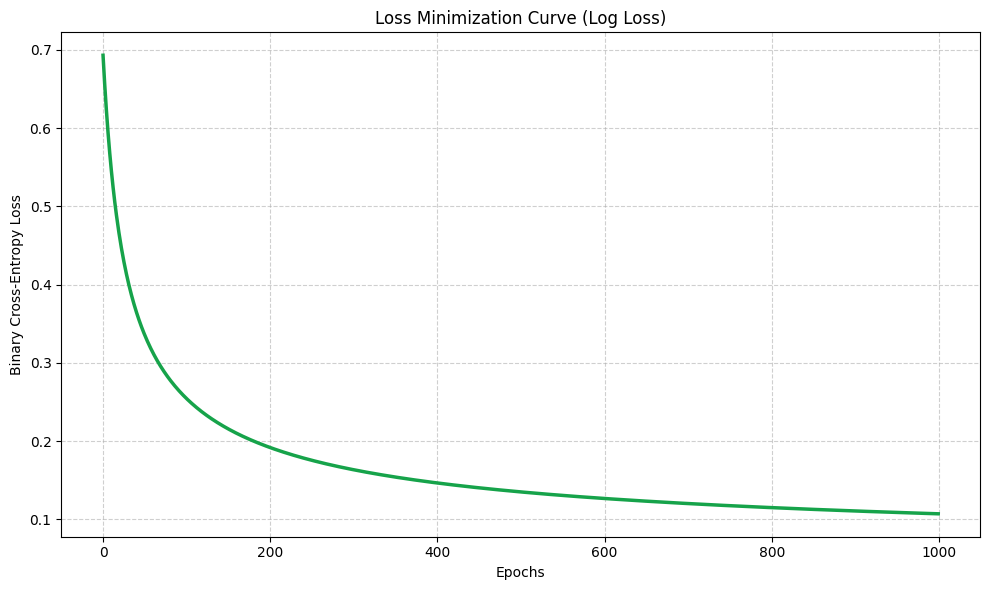

In [15]:
# Custom Logistic Regression training function using gradient descent
def custom_logistic_regression(X, y, learning_rate=0.01, epochs=1000):
    weights = np.zeros(X.shape[1])
    bias = 0.0
    loss_history = []

    for epoch in range(epochs):
        linear_score = np.dot(X, weights) + bias
        predicted_probability = sigmoid(linear_score)

        epsilon = 1e-15
        clipped_probability = np.clip(
            predicted_probability, epsilon, 1 - epsilon
        )
        loss = -np.mean(
            y * np.log(clipped_probability)
            + (1 - y) * np.log(1 - clipped_probability)
        )
        loss_history.append(loss)

        weight_gradient = np.dot(X.T, predicted_probability - y) / len(y)
        bias_gradient = np.mean(predicted_probability - y)

        weights -= learning_rate * weight_gradient
        bias -= learning_rate * bias_gradient

    return weights, bias, loss_history


# Train the custom model
custom_weights, custom_bias, loss_history = custom_logistic_regression(
    X_train, y_train, learning_rate=0.01, epochs=1000
)

# Predict using the custom model
custom_probability = sigmoid(np.dot(X_test, custom_weights) + custom_bias)
custom_pred = np.where(custom_probability >= 0.5, 1, 0)
custom_accuracy = accuracy_score(y_test, custom_pred)

print("Custom Logistic Regression Accuracy:", custom_accuracy)

# Visualize loss minimization

plt.figure(figsize=(10, 6))
plt.plot(loss_history, color="#16a34a", linewidth=2.5)
plt.title("Loss Minimization Curve (Log Loss)")
plt.xlabel("Epochs")
plt.ylabel("Binary Cross-Entropy Loss")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## 13. Comparison Table

In [16]:
# Compare the performance of both classifiers
comparison_table = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN"],
    "Accuracy": [logistic_accuracy, knn_accuracy],
    "Precision": [logistic_precision, knn_precision],
    "Recall": [logistic_recall, knn_recall],
    "F1 Score": [logistic_f1, knn_f1]
})

comparison_table.set_index("Model").round(4)

,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression,0.9737,0.9762,0.9535,0.9647
KNN,0.9474,0.9302,0.9302,0.9302


## 14. Interpretation and Conclusion

- Logistic Regression achieved **97.37% accuracy**, while KNN achieved **94.74% accuracy**.
- Logistic Regression achieved higher malignant-class precision, recall, and F1 score.
- Logistic Regression incorrectly classified three test samples.
- KNN incorrectly classified six test samples.
- **Logistic Regression is the better-performing classifier for this experiment.**

## Expected Learning Outcomes Achieved

- Implemented Logistic Regression and KNN using Scikit-learn.
- Applied preprocessing and feature scaling to a real-world dataset.
- Evaluated both models using accuracy, precision, recall, F1 score, and confusion matrix.
- Compared both classifiers using a comparison table.
- Recommended the better-performing classifier based on the results.